In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ternary

In [3]:
exp_points = {
    'liquid': [],
    'vapor': [],
}


In [30]:
def redraw(filename="vle_ternary.png"):
    fig, tax = ternary.figure(scale=1.0)
    fig.set_size_inches(13, 13)
    fig.set_dpi(400)

    tax.boundary()
    tax.gridlines(multiple=0.1, color="lightgray", linewidth=0.5, ls=":")

    tax.annotate("гексан, %", (1, 0, 0), ha="right",  va="center", fontsize=12)
    tax.annotate("вода, %",   (0, 1, 0), ha="center", va="bottom", fontsize=12)
    tax.annotate("спирт, %",  (0, 0, 1), ha="left",   va="center", fontsize=12)

    for e, w, h, label in exp_points["liquid"]:
        p = (h, w, e)
        tax.plot([p], marker="o", color="blue", markersize=5)
        if label:
            tax.annotate(label, (h, min(w + 0.01, 0.97), e), fontsize=9)

    for e, w, h, label in exp_points["vapor"]:
        p = (h, w, e)
        tax.plot([p], marker="^", color="red", markersize=5)

    ax = tax.get_axes()
    from ternary.helpers import project_point
    from matplotlib.lines import Line2D

    def draw_arrow_ternary(p_from, p_to, **kwargs):
        x0, y0 = project_point(p_from)
        x1, y1 = project_point(p_to)
        ax.annotate(
            "",
            xy=(x1, y1),
            xytext=(x0, y0),
            arrowprops=dict(arrowstyle="->", **kwargs),
        )

    for eL, wL, hL, eV, wV, hV, lbl in exp_tielines:
        pL = (hL, wL, eL)
        pV = (hV, wV, eV)
        tax.line(pL, pV, linewidth=1, color="green", alpha=0.7, marker=None)
        draw_arrow_ternary(pL, pV, color="green", linewidth=1, alpha=0.8)

    aze_w = 0.03
    aze_e = 0.12
    aze_h = 0.85
    aze_point = (aze_h, aze_w, aze_e)

    tax.plot([aze_point], marker="s", color="magenta", markersize=7)
    tax.annotate("азеотроп", (aze_h, min(aze_w + 0.01, 0.97), aze_e),
                 fontsize=10, color="magenta")

    mean_e, mean_w, mean_h = compute_local_mean_vapor()
    mean_point = (mean_h, mean_w, mean_e)
    tax.plot([mean_point], marker="D", color="black", markersize=6)
    tax.annotate("средний V", (mean_h, min(mean_w + 0.01, 0.97), mean_e),
                 fontsize=10, color="black")

    legend_elements = [
        Line2D([0], [0], marker="o", color="none", markerfacecolor="blue",
               markersize=7, label="жидкость"),
        Line2D([0], [0], marker="^", color="none", markerfacecolor="red",
               markersize=7, label="пар"),
        Line2D([0], [0], color="green", lw=1.5, label="связующая линия L–V"),
        Line2D([0], [0], marker="s", color="none", markerfacecolor="magenta",
               markersize=7, label="азеотроп"),
        Line2D([0], [0], marker="D", color="none", markerfacecolor="black",
               markersize=7, label="средний пар"),
    ]
    ax.legend(handles=legend_elements, loc="upper right", frameon=True)

    tax.clear_matplotlib_ticks()

    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


In [31]:
def compute_local_mean_vapor(center_e=0.12, center_w=0.03, center_h=0.85, sigma=0.10):
    ce, cw, ch = center_e, center_w, center_h

    weights = []
    vapors = []

    for eL, wL, hL, eV, wV, hV, _ in exp_tielines:
        vapors.append((eV, wV, hV))
        de = eV - ce
        dw = wV - cw
        dh = hV - ch
        d2 = de*de + dw*dw + dh*dh
        w = np.exp(-d2 / (2.0 * sigma * sigma))
        weights.append(w)

    weights = np.array(weights)
    vapors = np.array(vapors)

    if weights.sum() == 0:
        return ce, cw, ch

    mean = (weights[:, None] * vapors).sum(axis=0) / weights.sum()
    mean_e, mean_w, mean_h = mean

    s = mean_e + mean_w + mean_h
    if s > 0:
        mean_e /= s
        mean_w /= s
        mean_h /= s

    print(
        f"Средний пар: "
        f"вода = {mean_w*100:.2f}%, спирт = {mean_e*100:.2f}%, гексан = {mean_h*100:.2f}%"
    )

    return mean_e, mean_w, mean_h


In [32]:
def compute_mean_vapor():
    if not exp_tielines:
        return 0.0, 0.0, 0.0

    sum_e = sum(w[3] for w in exp_tielines)  # eV
    sum_w = sum(w[4] for w in exp_tielines)  # wV
    sum_h = sum(w[5] for w in exp_tielines)  # hV

    n = len(exp_tielines)
    mean_e = sum_e / n
    mean_w = sum_w / n
    mean_h = sum_h / n

    s = mean_e + mean_w + mean_h
    if s > 0:
        mean_e /= s
        mean_w /= s
        mean_h /= s

    print(f"Средний состав пара (V): вода = {mean_w*100:.2f} %, спирт = {mean_e*100:.2f} %, гексан = {mean_h*100:.2f} %")
    return mean_e, mean_w, mean_h


In [33]:
exp_tielines = []


def load_vle_table_csv(filename):
    global exp_tielines, exp_points

    df = pd.read_csv(filename, header=1)

    col_x_w = 'x_вода,%'
    col_x_e = 'x_спирт,%'
    col_x_h = 'x_гексан,%'
    col_y_w = 'y_вода,%'
    col_y_e = 'y_спирт,%'
    col_y_h = 'y_гексан,%'
    col_num = '№ опыта'

    required = [col_x_w, col_x_e, col_x_h, col_y_w, col_y_e, col_y_h]
    for col in required:
        if col not in df.columns:
            raise ValueError(f"В CSV нет обязательного столбца '{col}'")

    exp_tielines = []
    exp_points['liquid'].clear()
    exp_points['vapor'].clear()

    for _, row in df.iterrows():
        try:
            # жидкость: x
            wL = float(row[col_x_w]) / 100.0
            eL = float(row[col_x_e]) / 100.0
            hL = float(row[col_x_h]) / 100.0

            # пар: y
            wV = float(row[col_y_w]) / 100.0
            eV = float(row[col_y_e]) / 100.0
            hV = float(row[col_y_h]) / 100.0
        except Exception:
            continue
        sL = eL + wL + hL
        sV = eV + wV + hV
        if sL > 0:
            eL, wL, hL = eL / sL, wL / sL, hL / sL
        if sV > 0:
            eV, wV, hV = eV / sV, wV / sV, hV / sV

        if col_num in df.columns and not pd.isna(row[col_num]):
            label = f"{int(row[col_num])}"
        else:
            label = ""

        exp_tielines.append((eL, wL, hL, eV, wV, hV, label))

        exp_points['liquid'].append((eL, wL, hL, label))
        exp_points['vapor'].append((eV, wV, hV, label))

    print(f"Загружено: {len(exp_tielines)}")


Загружено: 21
Средний пар: вода = 5.68%, спирт = 13.50%, гексан = 80.83%


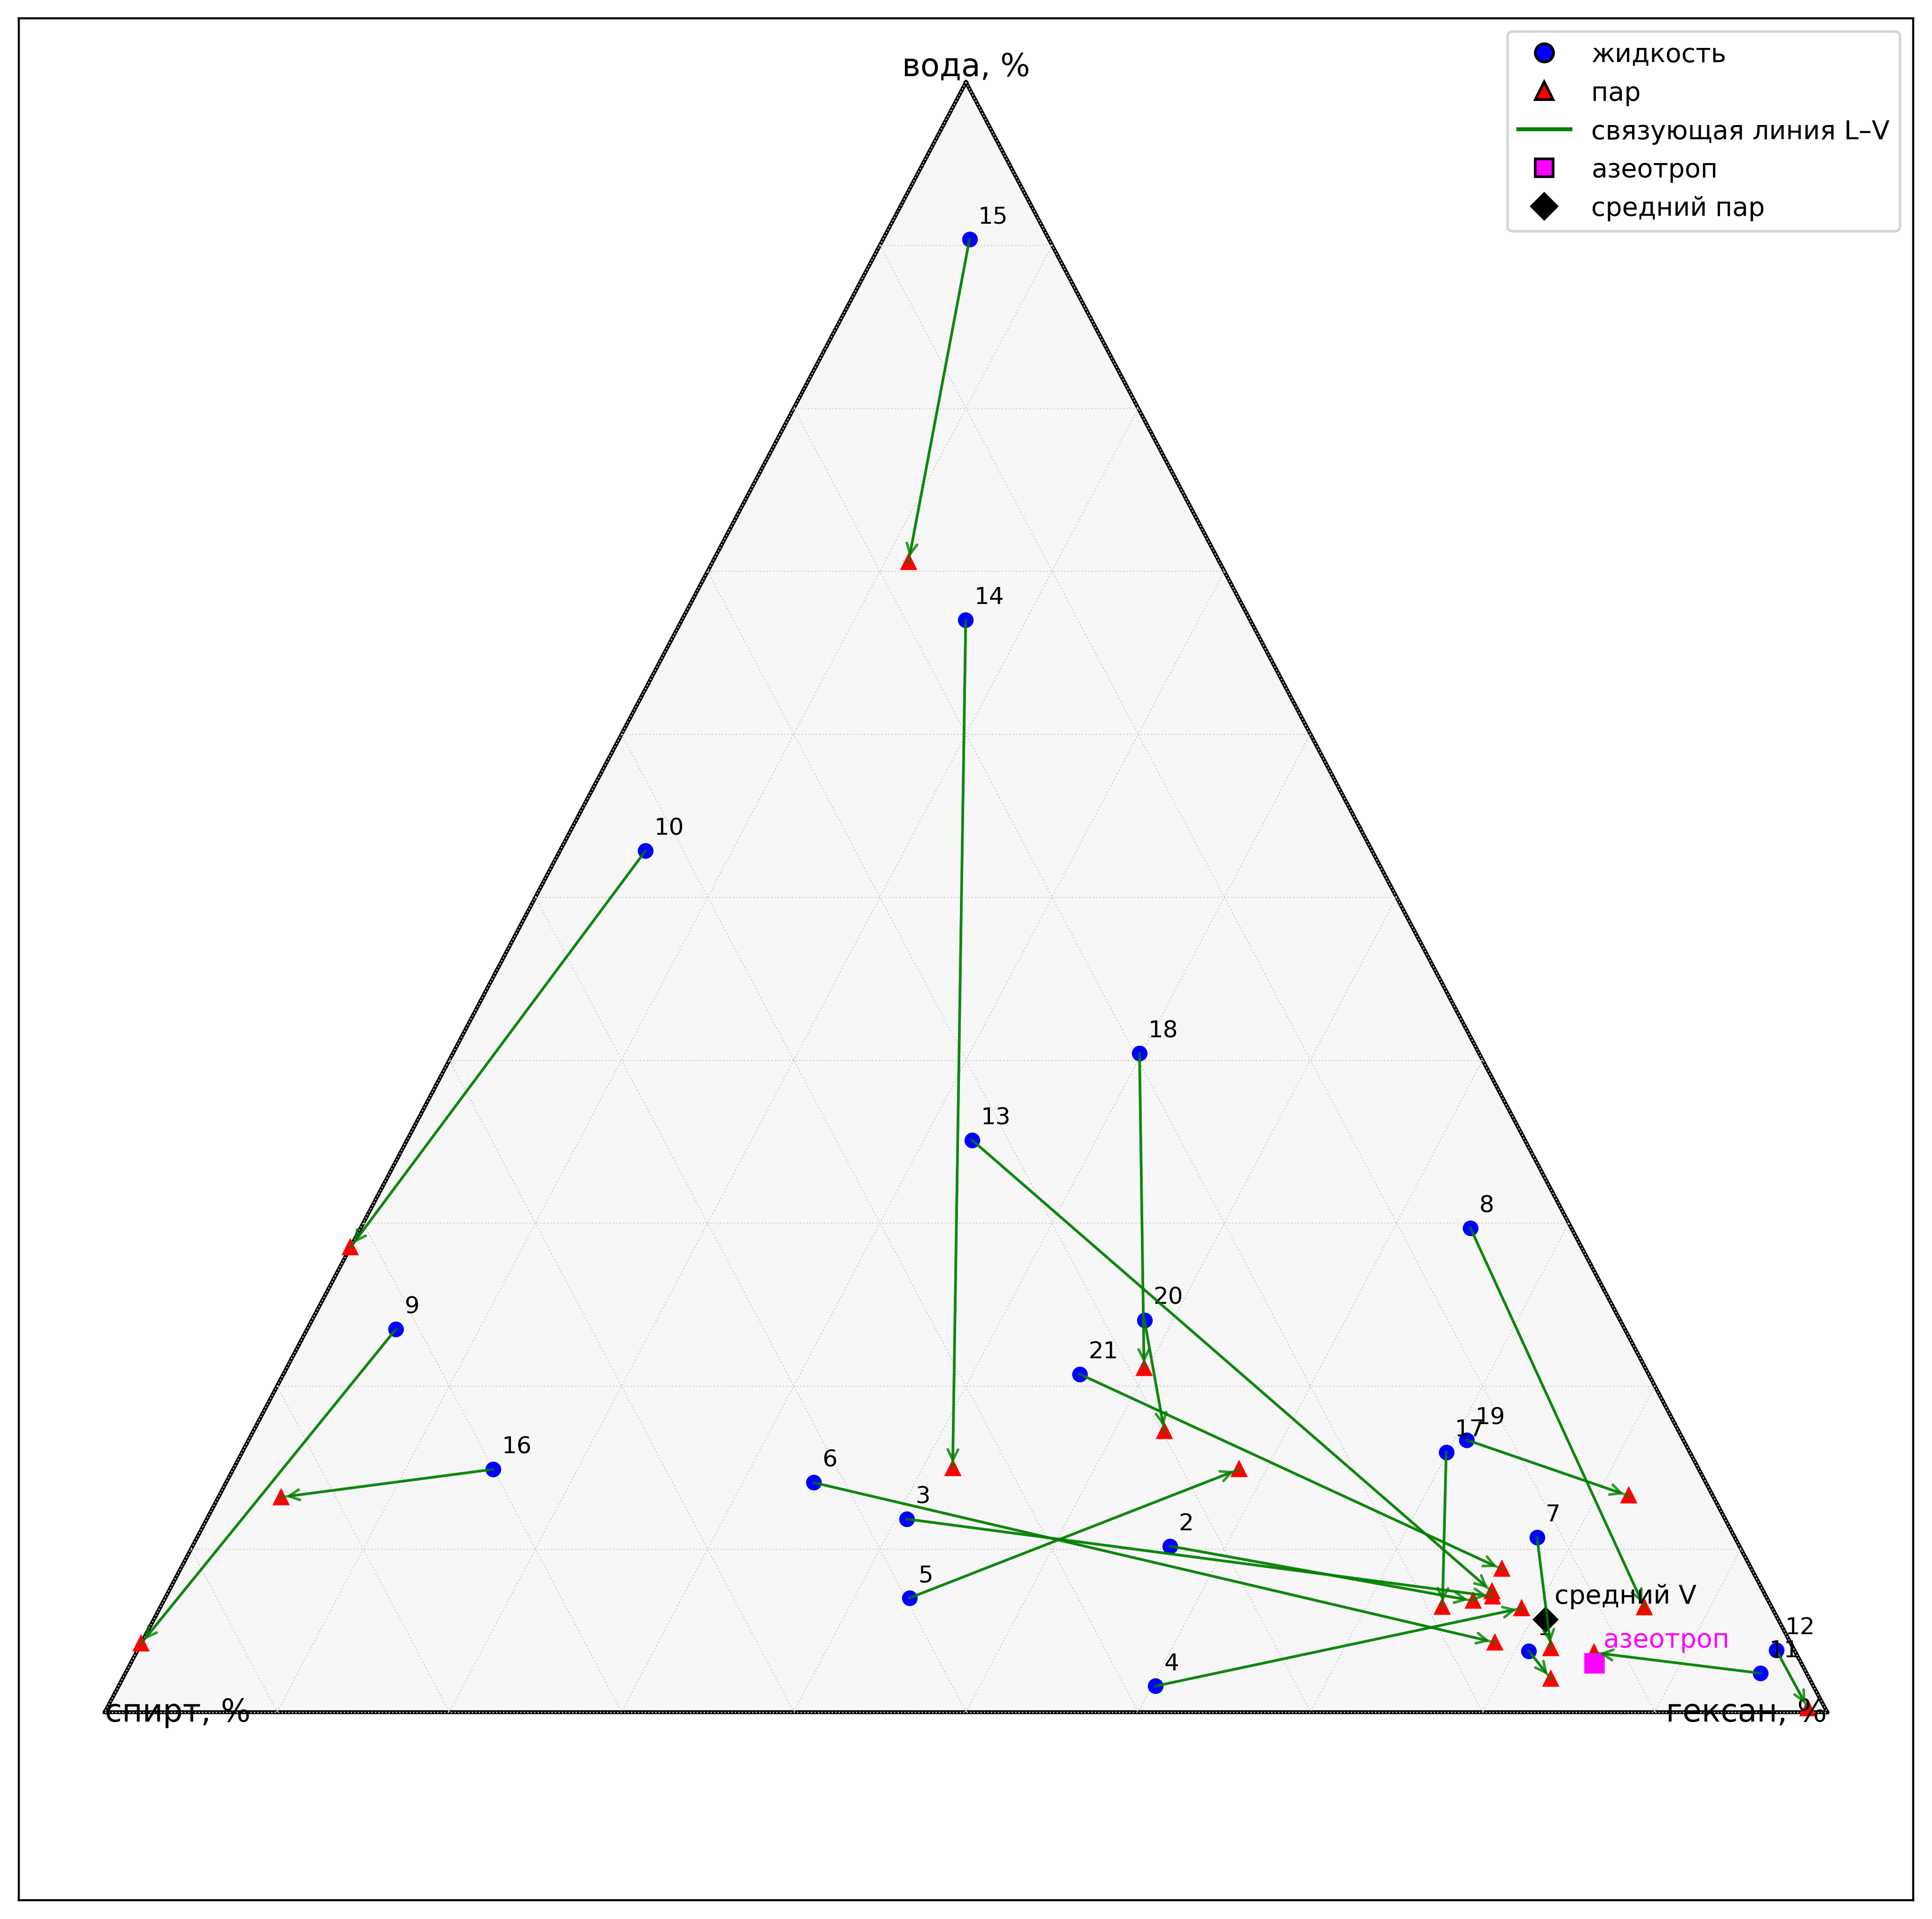

In [34]:
load_vle_table_csv("experiment-data/exp21.csv")
redraw("graphics/exp21.png")

# 